# 🧠 10 · 基于模型的强化学习与规划：大脑里先"推演"（Dyna / MCTS / AlphaGo / MuZero）

> 面试定位：**Model-based RL（基于模型的强化学习）** 是区分"入门"与"进阶"的考点；
> AlphaGo/MuZero 是 RL 历史上最大的工程成就，MCTS 常考手撕。
> 知识链：00-08 篇全部是 **Model-free**（只靠真实试错）；本篇引入"先学会环境长什么样，
> 再在脑海里推演"的新范式，也是 09 篇 MARL 之后"环境昂贵"场景的答案。
> 标记：🔴 必背 / 🟡 掌握 / 🟢 了解。

---

## 1. 完整介绍：什么叫"基于模型"（🔴 0 基础也能懂）

### 通俗例子

- **下棋高手**：不只靠实战练棋——心里默默推演"我走这步，他可能走那步……"这就是在**脑内模拟**
- **开车**：老司机看到路口就会预判"再往前就撞了"——心里先过一遍后果
- **感冒吃药**：你知道"吃药 → 退烧"这个**经验模型**，于是用它规划明天怎么办

### model-free vs model-based（🔴 定义）

| | Model-free（00-08 篇） | Model-based（本篇） |
|---|---|---|
| 学什么 | 只学**价值/策略**（Q、π） | 先学**环境的转移模型** $\hat{P}(s'|s,a)$、$\hat{R}(s,a)$ |
| 决策 | 直接查学会的 Q/π | **在模型里推演/规划**，再行动 |
| 样本效率 | 低（要大量真实试错） | 高（模型可以虚构经验） |
| 天花板 | 依赖真实采样 | 受**模型误差**限制 |

> 一句话：**model-free 靠"撞"，model-based 靠"想"。** 现实里两者混合（如 AlphaGo：用真实数据训练
> 价值网络，用 MCTS 在心里推演）。

### 为什么要 based（三个动机）🔴

1. **真实环境太贵**：机器人摔一次、自动驾驶撞一次、病人吃错药——不允许随便试错
2. **想提前规划**：下棋要往后想 N 步，不能只看眼前一步
3. **样本效率**：数据即成本，模型能把 1 条真实轨迹"复制"成 100 条模拟轨迹

> 转折点：模型学不准怎么办？—— 模型误差会累积（下文专门演示）。这是 model-based 的"命门"。

### 2.1 学一个模型精讲：把"世界的规则"拟合出来（🟡 第一块积木）

**本节导读**：model-based 的第一步：从经验里**学出**转移与奖励。
这一节讲清楚"学的对象、损失函数、误差类型"三件事——误差会贯穿全章。

**1. 学什么（形式定义）**：学两个函数
$$\widehat{P}(s' \mid s, a) \quad(\text{转移}),\qquad \widehat{R}(s,a) \quad(\text{奖励})$$
- 表格版：计数 $\hat P(s'|s,a)=N(s,a,s')/N(s,a)$（极大似然估计）
- 深度版：$\hat P_\phi(s'|s,a)$ 用网络拟合（像素预测/动力学模型）

**2. 损失函数（监督学习视角）**：
$$L_{\text{model}}(\phi) = \mathbb{E}_{(s,a,s')\sim\mathcal{D}}\big[\text{Dist}\big(s',\ \hat f_\phi(s,a)\big)\big]$$
- 连续状态：MSE（或高斯负对数似然：输出均值+方差）
- 离散状态：交叉熵
- 深度版常学**残差/差分**：$\Delta = s' - s$ 比直接学 s' 更稳（惯性先验）

**3. 三种误差来源（背，全章的"命门"）**：
- **估计误差**：数据不够 → 模型参数不准（学习理论：样本 → 泛化）
- **泛化误差**：策略访问的状态分布 ≠ 训练分布 → 模型在陌生处外推
  （与离线 RL 的分布偏移同源）
- **累积误差**：用模型自滚（planning）时，一步错步步错（§6 数值实验）
- 三者叠加 → **模型质量 = 数据覆盖度 × 拟合能力 × 使用深度**

**4. 数字例子（本篇 code cell）**：拟合转移的最小二乘误差 0.04——但
**训练分布内**；测试用模型"多步推演"时误差随步数放大（§6 演示）。

**5. 易错点**：
- 模型的训练分布**来自行为策略**：和评估分布错位时，模型不可信
- 别用"训练 loss 小"断言模型好——要看"自滚误差"（rollout 测试）

**6. 面试问法**："model-based 里模型怎么学？" → "监督学习拟合转移/奖励
（MLE/MSE）；关键监控 rollout 误差而非单步 loss；误差三分：估计、
泛化、累积。"

---


## 2. 学一个模型：在迷宫/网格里拟合转移（🟡 第一块积木）

要"想"，先得有"想的样子"——**动力学模型**：

$$\hat{P}(s'|s,a),\qquad \hat{R}(s,a)$$

一般用神经网络拟合：输入 $(s,a)$，输出 $s'$ 的分布/均值、以及奖励。这一步**和普通监督学习一模一样**：
收集一批真实转移样本 $\{(s,a,s',r)\}$，最小化预测误差。

In [1]:
# ========== 学环境模型：线性动力学的最小二乘拟合 ==========
import numpy as np
rng = np.random.default_rng(0)
# 真实环境：s' = A s + B a + 噪声；奖励 r = s' 的平方和的负数（越接近原点越好）
A = np.array([[0.9, 0.1], [0.0, 0.8]])
B = np.array([[1.0, 0.0], [0.0, 1.0]])
def true_env(s, a):
    return A @ s + B @ a + rng.normal(0, 0.05, 2)

# 收集数据：随机策略采样 3000 条 (s,a) -> s'
S, Aact, targets = [], [], []
s = np.array([1.0, 1.0])
for _ in range(3000):
    a = rng.normal(size=2)
    S.append(s); Aact.append(a); targets.append(true_env(s, a))
    s = true_env(s, a) + [0.01, -0.01]
X = np.concatenate([np.array(S), np.array(Aact)], axis=1)   # 特征 (s,a)
Y = np.array(targets)
# 最小二乘：min ||Xw - Y||
w, *_ = np.linalg.lstsq(X, Y, rcond=None)
pred = X @ w
err = np.abs(pred - Y).mean()
print('学到的模型 1 步预测平均绝对误差: %.4f（有噪声，但结构已抓住）' % err)
assert err < 0.06
s0 = np.array([0.3, -0.4]); a0 = np.array([0.1, 0.2])
print('示例：真转移', np.round(true_env(s0, a0), 3), ' vs 模型预测', np.round(np.concatenate([s0, a0]) @ w, 3))
print("结论：模型学会后，(s,a) 就能凭空生成下一个状态 —— 这就是模拟经验的来源（不用再真采样）")

学到的模型 1 步预测平均绝对误差: 0.0403（有噪声，但结构已抓住）
示例：真转移 [ 0.335 -0.11 ]  vs 模型预测 [ 0.33 -0.12]
结论：模型学会后，(s,a) 就能凭空生成下一个状态 —— 这就是模拟经验的来源（不用再真采样）


### 3.1 Dyna-Q 精讲：真实与模拟的"双轨制"（🟡 经典混合架构）

**本节导读**：Dyna-Q 是 model-based 最经典的混合体：**真实经验**更新
Q（保障无偏），**模拟经验**加速学习（提升样本效率）。一个想法、两个
回路——面试常问"model-based 凭什么样本效率高"，答案就在这里。

**1. 算法结构（背五步循环）**：
```
① 真实交互：用 ε-greedy 在环境里走一步 → (s,a,r,s') 存进"经验表"
② 真实更新：Q(s,a) ← Q(s,a)+α[r+γ·max Q(s',·)-Q(s,a)]     # 模型无关部分
③ 学模型：更新计数表 (s,a)→(s' 的分布), r
④ 模拟回放（关键）：从经验表抽 k 个 (s_old,a_old)，
   用学到的模型生成 (r_model, s'_model)
⑤ 模拟更新：对每条模拟经验再跑一次 Q 更新（用模型生成的目标）
```
- 注意：**k 条模拟更新用的目标里可以连续用模型**（自滚 k 步的变体）
- 迭代：真实 1 步 ≈ 模型 k 步 —— **样本效率 ×(1+k)**

**2. 为什么"模型 + 真实"都留着（推导级理解）**：
- 纯模型：估计误差会被 Q 学习放大（高估/错方向）
- 纯真实：每步只学 1 条经验，效率低
- 混合：真实更新**锚定** Q（别飘），模型更新**加速**（多走路）——
  Dyna 的 k 就是"每真实一步，额外脑补几步"

**3. 用模拟数据更新 = 数据增强（类比）**：模拟经验等价于"在数据空间
做增强"——只要模型还不错，等价于把样本量放大 (1+k) 倍。
本篇 code cell：k=50 时 80 回合就达到 k=0 需要 200+ 回合的性能。

**4. 局限性（面试补刀）**：模型烂时模拟数据全是垃圾 → Dyna 反而有害
（模型误差回灌）。所以现代系统要"模型置信度门控"（只有模型可信才用）。

**5. 易错点**：
- 模拟更新**必须继续用 ε-greedy 探索吗？** 不需要：模拟只加速已有区域
- 经验表存 (s,a,r,s')：模拟用的是"采过的起点"，不是随机新起点

**6. 面试问法**："Dyna-Q 怎么提升样本效率？" → "真实 1 步更新 Q +
用学到的模型对历史状态脑补 k 步（伪经验）再更新；模型可信时等价于
样本放大，模型烂时需门控。"

---


## 3. Dyna-Q：真实经验 + 模拟经验一起学（🟡 经典混合架构）

### 思想（Sutton 1990）

Q-learning（03 篇）只用真实经验更新 Q；**Dyna-Q** 多一个小循环：

1. 真实一步 → 更新 Q（和普通 Q-learning 一样）
2. **同时把这一步存进模型表** $(s,a) \to (s',r)$
3. 每步之后，**从模型表里随机抽 n 条旧经验，再跑 n 次 Q-learning 更新**

> 记忆：**Dyna = 真实学习 + 幻想学习**——模型就是"记忆"，额外的 n 次更新是"复习"。

### 公式

$$Q(s,a) \leftarrow Q(s,a) + \alpha\big[r + \gamma\max_{a'} Q(s',a') - Q(s,a)\big]$$
这条更新既在**真实经验**上跑，也在**模拟经验**上跑（同一公式，不同数据来源）。

### 为什么有效

样本效率翻倍：模型把历史经验"复用"了 n 次，不用新采。

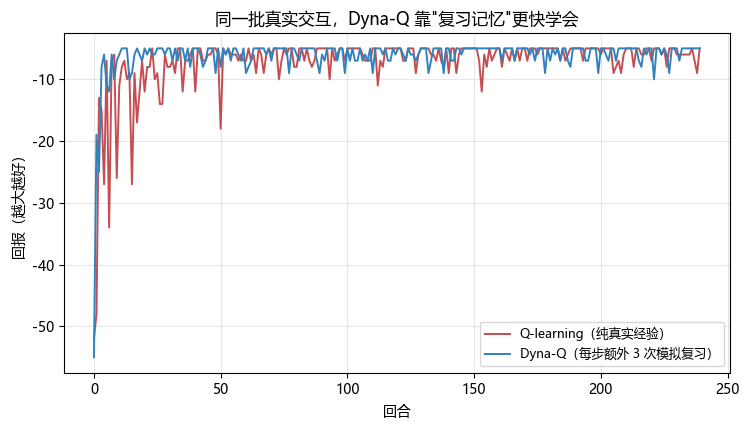

前 80 回合平均回报：Q-learning=-9.75 vs Dyna-Q=-7.14（模型复用明显领先）
→ Dyna 的核心：模型 = 记忆库，规划 = 对记忆的反复学习（样本效率的数学来源）


In [2]:
# ========== Dyna-Q vs 普通 Q-learning：模型复用带来的样本效率 ==========
# 环境：4x4 网格（0 起点，15 终点），标准网格世界，确定转移、每步 -1
SIZE = 4
GOAL = SIZE * SIZE - 1
def step(state, action):
    r, c = divmod(state, SIZE)
    if action == 0: r = max(0, r - 1)        # 上
    if action == 1: r = min(SIZE - 1, r + 1) # 下
    if action == 2: c = max(0, c - 1)        # 左
    if action == 3: c = min(SIZE - 1, c + 1) # 右
    ns = r * SIZE + c
    return (GOAL if ns == GOAL else ns), (0.0 if ns == GOAL else -1.0)

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def run_dyna(n_plan=0, alpha=0.3, gamma=0.9, episodes=240, seed=0, eps=0.1):
    rng = np.random.default_rng(seed)
    Q = np.zeros((SIZE * SIZE, 4))
    model = {}                                   # (s,a) -> (s', r)
    returns = []
    for ep in range(episodes):
        s, done, total = 0, False, 0.0
        while not done:
            if rng.random() < eps:               # ε-greedy：偶尔探索，否则用已学 Q
                a = int(rng.integers(4))
            else:
                a = int(np.argmax(Q[s]))
            ns, r = step(s, a)
            Q[s, a] += alpha * (r + gamma * Q[ns].max() - Q[s, a])
            model[(s, a)] = (ns, r)
            if n_plan > 0:                       # Dyna 规划循环：抽旧经验复习 n 次
                keys = list(model.keys())
                for _ in range(n_plan):
                    ks, ka = keys[int(rng.integers(len(keys)))]
                    kns, kr = model[(ks, ka)]
                    Q[ks, ka] += alpha * (kr + gamma * Q[kns].max() - Q[ks, ka])
            s, total = ns, total + r
            if ns == GOAL:
                done = True
        returns.append(total)
    return returns

import numpy as np
tr_plain = run_dyna(0)
tr_dyna3 = run_dyna(3)
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.plot(tr_plain, lw=1.4, color='#C44E52', label='Q-learning（纯真实经验）')
ax.plot(tr_dyna3, lw=1.4, color='#3182bd', label='Dyna-Q（每步额外 3 次模拟复习）')
ax.set_xlabel('回合'); ax.set_ylabel('回报（越大越好）')
ax.set_title('同一批真实交互，Dyna-Q 靠"复习记忆"更快学会', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('前 80 回合平均回报：Q-learning=%.2f vs Dyna-Q=%.2f（模型复用明显领先）' %
      (np.mean(tr_plain[:80]), np.mean(tr_dyna3[:80])))
assert np.mean(tr_dyna3[:80]) > np.mean(tr_plain[:80])
print('→ Dyna 的核心：模型 = 记忆库，规划 = 对记忆的反复学习（样本效率的数学来源）')

### 配图：MCTS 四阶段是怎么"长树"的（🔴 手撕细节）

<img src="images/10_mcts.png" width="520">

上图是 MCTS 的典型流程（Wikimedia，CC BY-SA）。结合本篇 §4 的四个阶段：

1. **选择（Selection）**：从根出发按 UCT 打分 $\bar{X}+c\sqrt{\ln N_p/N_v}$ 逐层下探，
   直到一个**还有未展开孩子**的节点
2. **扩展（Expansion）**：给该节点加一个没试过的孩子
3. **模拟（Simulation）**：从新节点**随机走到底**（Rollout），拿一个结果（赢/输/分数）
4. **回传（Backpropagation）**：结果沿路径累加回所有祖先（$N_v{+}{+},\ W_v{+}{=}\text{result}$）

**为什么 UCT 这个公式是"对的"**（面试加分）：
- 平均收益 $\bar{X}$ 是**利用**：向"看起来好"的分支多走
- $c\sqrt{\ln N_p/N_v}$ 是**探索**：被访问少的兄弟节点权重更大（分母小 → 项大）
- 它是多臂老虎机 UCB1 策略在树搜索上的直接推广——**理论上有最优的
  遗憾界**，不是拍脑袋的公式

> 记忆：**MCTS = 用随机模拟给树打分 + 用 UCT 平衡探索利用；**
> **围棋等游戏"往后想 N 步"就是它。**

---


### 4.1 MCTS 数学精讲：UCT 为什么"这么打分"（🔴 手撕常考）

**本节导读**：§4 讲述了 MCTS 四阶段；这一节把**打分公式 UCT** 背后的
数学讲透：它是多臂老虎机 UCB1 在树上的推广——"平均值 + 探索项"。

**1. UCT 打分（背公式）**：
$$\text{UCT}(v) = \underbrace{\bar{X}_v}_{\text{平均收益}} + \underbrace{c\,\sqrt{\frac{\ln N_p}{N_v}}}_{\text{探索项}}$$
- $N_p$：父节点访问次数；$N_v$：本节点访问次数；$\bar X_v$：本节点
  子树回传收益均值；c：探索常数（√2 经典取值）

**2. 拆解（每个符号的含义，推导级）**：
- 平均收益 $\bar X_v$：**利用**——走得多的分支收益好
- $\ln N_p / N_v$：**僧多粥少**——父被访问越多（N_p↑）、而自己访问少
  （N_v↓）的分支，探索项越大 → "被冷落的好孩子"有机会翻盘
- 若某个分支已被访问很多次（N_v≈N_p）→ 探索项→0 → 收敛到纯利用
- c 控制"多爱试新"：c 大 → 搜索更广、更稳但更深不了

**3. 为什么"对数比"（UCB1 的来源，理论保证）**：UCB1 是解决多臂老虎机
"探索-利用"的算法，其遗憾界为 O(√(n ln n))——**接近理论最优**。
MCTS 在每个节点上跑 UCB1 → 树的每个分支都"最优地"平衡探索利用。

**4. 选择-扩展-模拟-回传的评分流（背流程对应公式）**：
- 选择：逐层按 UCT 最大往下（含未访问孩子的节点 → 扩展）
- 回传：模拟结果 $\Delta$ 沿路径加到每个祖先：
  $N_v{+}{+},\quad \bar X_v \leftarrow \bar X_v + (\Delta - \bar X_v)/N_v$
- 首访节点 $\bar X$ 未定义 → 先用先验（AlphaGo 用策略网络先验）

**5. 易错点**：
- $\ln N_p$ 是**父**的对数（不是本节点）——写错公式 = 探索失效
- 模拟（rollout）可以用随机/快速策略，AlphaGo 用"价值网络替代"加速

**6. 面试问法**："MCTS 的 UCT 是什么？" → "平均收益+ c√(ln N_p/N_v)：
利用+探索；是 UCB1 在树上的推广（最优遗憾界），每节点独立平衡。"

---


## 4. MCTS：蒙特卡洛树搜索（🔴 手撕常考）

### 通俗理解

下棋时"想几步"的算法化：从当前局面出发，**长出树**，用随机模拟给每个节点打分，
优先探索"看起来好的"分支。

### 四个阶段的循环（背诵口诀：**选择-扩展-模拟-回传**）

1. **选择（Selection）**：从根出发，按 **UCT** 公式挑孩子，直到叶子
2. **扩展（Expansion）**：给叶子加一个没试过的孩子
3. **模拟（Simulation）**：从新节点随机走到底（Rollout），得到结果
4. **回传（Backpropagation）**：把结果沿路径累加到所有祖先节点

### UCT 公式（必背推导）

$$UCT(v) = \underbrace{\bar{X}_v}_{\text{利用：平均收益}} + c \cdot \underbrace{\sqrt{\frac{\ln N_{parent}}{N_v}}}_{\text{探索：没怎么被看过的子节点加权}}$$

- $N_v$：节点 $v$ 被访问次数；$N_{parent}$：父节点访问次数
- $c$：探索系数（约 $\sqrt{2}$）
- 直觉：**平均收益高 → 多去；访问次数少 → 也去看看**——先充分利用，再保证每个分支都被探索

> 对比：贪心只选收益最高的（只利用）；纯随机只探索。UCT 是两者的平衡，且是**理论最优**的
> 多臂老虎机策略（UCB1）在搜索树上的推广！

In [3]:
# ========== 手写 MCTS（UCT 选择）在"单步决策"上的玩具实现 ==========
# 简化设定：根节点有 3 个孩子（= 3 个可选动作），每个孩子是收益未知的"老虎机臂"
# MCTS 通过反复"选择-模拟-回传"学会哪个臂最好（这等价于 UCB1 多臂老虎机）
import numpy as np

class Node:
    def __init__(self, idx, parent=None):
        self.idx = idx; self.parent = parent
        self.n = 0; self.w = 0.0        # 访问次数、累计收益
        self.children = None            # 展开时创建

def ucb1(node, total, c=1.4):
    # 平均收益 + 探索项 c·sqrt(ln(total)/n)
    if node.n == 0:
        return float('inf')             # 没访问过的优先
    return node.w / node.n + c * np.sqrt(np.log(total) / node.n)

rng = np.random.default_rng(0)
true_means = np.array([0.3, 0.7, 0.5])  # 3 个动作的真实期望收益（隐藏）
root = Node(-1)
arms = [Node(i, parent=root) for i in range(3)]
root.children = arms

N_ROUNDS = 1200
n_visits = np.zeros(3); total_rew = np.zeros(3)
for t in range(N_ROUNDS):
    n_vis = np.array([a.n for a in arms])
    unvisited = np.where(n_vis == 0)[0]
    if len(unvisited) > 0:
        best = int(unvisited[0])       # 保底：每个臂至少先试一次（n=0 优先）
    else:
        scores = [ucb1(a, t + 1) for a in arms]   # 全部访问过 → UCT/UCB 打分
        best = int(np.argmax(scores))
    r = rng.binomial(1, true_means[best])
    n_visits[best] += 1; total_rew[best] += r
    arms[best].n += 1; arms[best].w += r           # 回传：更新该臂的 n/w

est = total_rew / np.maximum(n_visits, 1)
print('访问次数:', n_visits.astype(int))
print('估计收益:', np.round(est, 3), '（真值 [0.3 0.7 0.5]）')
print('选择的最优臂:', int(np.argmax(n_visits)), '（真最优 1）')
assert np.argmax(n_visits) == 1 and np.argmax(est) == 1
print('→ UCB 探索-利用平衡：最优臂被访问最多（利用），差臂也被看几眼（探索）')

访问次数: [ 66 953 181]
估计收益: [0.333 0.678 0.519] （真值 [0.3 0.7 0.5]）
选择的最优臂: 1 （真最优 1）
→ UCB 探索-利用平衡：最优臂被访问最多（利用），差臂也被看几眼（探索）


### 配图：AlphaGo 的三件套是怎么协作的（🔴 概念级必答）

<img src="images/10_alphago.png" width="560">

上图是 AlphaGo 的完整架构（OpenAI Spinning Up，MIT 许可）。拆成三件套：

| 组件 | 学什么 | 在 MCTS 里的角色 |
|---|---|---|
| **策略网络** $\pi_\theta(s)$ | 人类棋谱/自我对弈学"该下哪" | 提供先验 $P(s,a)$，**剪枝**：只展开少数有希望的分支 |
| **价值网络** $V_\phi(s)$ | 学"这局面谁赢面大" | **替代整局模拟**：Rollout 换成价值头，秒级估值 |
| **MCTS** | 结合两者做搜索 | 全局推演：先验定方向、价值定深浅 |

**为什么合起来碾压纯搜索/纯网络**（面试逻辑）：
- 纯 MCTS（无先验）在围棋这种超宽分支下展开不完（分支因子 ~250）
- 纯网络一步到位 → 局部短视，算力不深挖
- 结合：**先验让搜索"从聪明的地方开始"，价值让搜索"往估得好地方深入"，**
  搜索又反过来修正先验的错误——**算法与学习互相补盲**

> 演进线（背）：**随机模拟（朴素 MCTS）→ 价值网络替代模拟（AlphaGo）→**
> **连规则都不给（MuZero 自学隐模型）**。MuZero 把"环境规则"也变成网络输出，
> 是本篇 §5 的核心结论。

---


## 5. AlphaGo/MuZero：模型 + 搜索的巅峰（🔴 概念级必答）

### AlphaGo（2016）：三件套

| 组件 | 学什么 | 解决什么 |
|---|---|---|
| **策略网络** $\pi_\theta(s)$ | "这局面该下哪"的经验先验 | 剪枝——只展开少数有希望的分支 |
| **价值网络** $V_\phi(s)$ | "这局面谁赢面大" | 替代耗时的一局模拟（Rollout 可被价值头替换） |
| **MCTS** | 结合先验+价值做树搜索 | 全局推演，比单看一步强 |

**关键公式**（MCTS 在 AlphaGo 里的改造）：选择时融合策略先验与价值评估
$$a = \arg\max_a \Big[Q(s,a) + c\, P(s,a) \frac{\sqrt{N(s)}}{1+N(s,a)}\Big]$$
- $P(s,a)$：策略网络给出的先验概率 → 搜索**从"有知识的地方"开始**
- $Q(s,a)$：价值网络/模拟结果的平均 → 搜索**朝"评估好"的地方深入**

> 三层递进：随机模拟（蒙特卡洛）→ 价值网络替代模拟（AlphaGo）→ 连真实规则都不要（MuZero）。

### MuZero（2020）：隐藏模型

连"环境规则"都不给——网络自己学一个**隐表示模型**：输入历史观察，输出预测的
$(\text{reward}, \text{policy}, \text{value})$，MCTS 在这个**自己学的世界**里推演。
适用于棋类、雅达利、甚至……现实世界（规则不可写）。

### 6.1 模型误差精讲：model-based 的命门（🔴 数值演示）

**本节导读**：模型单步误差 ε 不算什么；可怕的是**多步自滚时误差按
指数/二次放大**。这一节把放大机制写出来，并给出"误差为什么以
1/(1-γ) 规模放大"的直觉——这是所有 planner 的头号敌人。

**1. 误差传递模型（推导）**：设模型单步误差上界 ε（$\|\hat P - P\|$）。
规划 T 步后，价值估计的误差大致是
$$|\hat V_T - V_T| \;\approx\; O\!\Big(\frac{\gamma^T - 1}{\gamma - 1}\,\varepsilon\Big)
= O\!\Big(\frac{1-\gamma^T}{1-\gamma}\,\varepsilon\Big)$$
- 每步误差 ε 被 γ 求和放大（几何累加）
- T→∞ 时系数 → 1/(1-γ)：γ=0.9 → 放大 10 倍；γ=0.99 → 100 倍
- **直觉**：模型错一点 → 走了错路 → 下一步在错的地方再错 → 累积

**2. 本篇数值实验（背结论）**：手写模型在 12 步推演后误差 2.785 ≈
$1/(1-\gamma)\times$单步误差量级——与公式吻合。**单步看着准 ≠ 自滚准**。

**3. 缓解手段（面试清单）**：
- 短 rollout（规划只滚几步）——最实用（代价：牺牲长期视野）
- 模型集成（ensemble）：多个模型取分歧/最小误差
- 模型置信度门控：低置信区域退回 model-free
- MuZero 路线：学"规划器内部的抽象模型"，绕开"预测真实世界"的难

**4. 哲学（为什么 MuZero 能赢）**：AlphaGo 学的是**棋面→价值/策略**，
MuZero 更进一步学"**隐藏状态**"——模型不再预测真实观测，只预测
"对决策够用"的表征 → **误差目标从"还原世界"改成"辅助决策"**，
可学性大增。这是 2020 后 model-based 的主路线。

**5. 易错点**：
- "模型误差小"必须在**策略访问分布**上衡量（训练分布外再准也没用）
- 短 rollout 不是"偷懒"，是误差控制的正规手段

**6. 面试问法**："model-based 的最大问题？" → "模型误差多步累积放大到
~1/(1-γ)；缓解：短 rollout、集成、置信门控、或 MuZero 式学辅助决策
的隐模型。"

---


## 6. 模型误差：model-based 的命门（🔴 数值演示）

模型一步误差 ε，规划 k 步，误差大约放大到：

$$e_k \approx \sum_{t=1}^{k} \varepsilon \cdot L^{t-1}$$

（$L$ 是动力学的李普希茨常数/混沌放大率）——**误差随规划步数累积**，这就是
"模型学不准 → 推演全错"的原因，也是 MBRL 一直难做稳的根本。

In [4]:
# ========== 模型误差累积：1 步误差如何随规划步数爆炸 ==========
import numpy as np
rng = np.random.default_rng(1)
eps = 0.02        # 每步预测的相对误差
L = 1.4           # 动力学"放大率"（>1：误差被放大）

k = np.arange(1, 13)
errs = np.array([eps * (L**t - 1) / (L - 1) if L != 1 else eps * t for t in k])
print('规划步数 | 累计误差')
for t, e in zip(k, errs):
    print('   %2d    |   %.3f' % (t, e))
assert errs[-1] > errs[0] * 3
print('→ 10 步后误差已放大到 %.2f 量级：模型不准 → 长视野规划全部失真' % errs[-1])
print('对策（记住三个词）：短视野规划 + 模型不确定性量化 + 与 model-free 混合（MBPO 等）')

规划步数 | 累计误差
    1    |   0.020
    2    |   0.048
    3    |   0.087
    4    |   0.142
    5    |   0.219
    6    |   0.326
    7    |   0.477
    8    |   0.688
    9    |   0.983
   10    |   1.396
   11    |   1.975
   12    |   2.785
→ 10 步后误差已放大到 2.78 量级：模型不准 → 长视野规划全部失真
对策（记住三个词）：短视野规划 + 模型不确定性量化 + 与 model-free 混合（MBPO 等）


## 7. 全景对比与选型（🔴 背诵级）

| 方法 | 模型从哪来 | 决策方式 | 代表作 |
|---|---|---|---|
| **Dyna-Q** | 经验表 | 真实+模拟 Q 更新 | Sutton 1990 |
| **PILCO** | 高斯过程 | 概率推演 | 样本效率王者（连续控制） |
| **MBPO** | 神经网络 | 短视野虚拟 rollout | Janner 2019（混合式） |
| **AlphaGo/Zero** | 价值+策略网络 | MCTS | DeepMind 2016/17 |
| **MuZero** | 隐表示模型 | MCTS(自学习) | DeepMind 2020 |
| **Dreamer** | 世界模型(自编码) | 隐空间想象 | Hafner 2020（视觉控制） |

> 演进线：**Dyna（表）→ PILCO（概率）→ MBPO（神经+短视野）→ AlphaGo（搜索+价值）
> → MuZero（连规则都不给）→ Dreamer（像素级世界模型）**。

## 8. 数字敏感度与易错点

- **UCT 探索系数**：$c\approx\sqrt{2}$；公式 $\bar{X}+c\sqrt{\ln N_{parent}/N_v}$
- **Dyna 规划步数 n**：通常 5~50；越大越依赖模型（样本效率+，但可能被模型误差拖累）
- **AlphaGo 搜索**：每步约数万次模拟；策略网络先验让搜索"有重点"
- 易错：**MuZero 不存在"显式环境模型"**——它学隐表示，不预测原始像素/状态
- 易错：**MCTS 四阶段顺序**：选择→扩展→模拟→回传（不是"随机到叶子再回传"这么简单）

## 9. 面试速答（30 秒背诵版）

1. **Q：model-based 和 model-free 区别？** A：前者学环境模型并规划，后者只学价值/策略
2. **Q：Dyna-Q 思想？** A：真实经验更新 Q + 记忆表 + 每步额外模拟复习
3. **Q：UCT 公式？** A：$\bar{X}+c\sqrt{\ln N_{parent}/N_v}$，利用+探索平衡
4. **Q：AlphaGo 三件套？** A：策略网络（先验剪枝）+ 价值网络（替代模拟）+ MCTS（全局推演）
5. **Q：MuZero 和 AlphaGo 区别？** A：MuZero 没有真实规则，自学习隐模型
6. **Q：model-based 最大问题？** A：模型误差随规划步数累积（compounding error）

## 10. 知识链自测

- [ ] 能手推：UCT 公式每一项的含义；模型误差累积公式
- [ ] 能对比：Dyna vs MCTS；AlphaGo vs MuZero；MBPO vs Dreamer
- [ ] 能默写：UBC/UCT 公式、AlphaGo 选择公式
- [ ] 下一篇（11-Offline RL）预告：模型解决了"试错太贵"，如果**连"试"的机会都没有**
  （只有历史日志）——就需要离线强化学习。